# 03 - Feature Engineering

**Goal:** We applied **nine** feature engineering techniques. All logic lives in `ml/src/features.py` so the training notebooks and the live prediction service use exactly the same code (no training-serving skew).

In [28]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parents[1] / "ml" / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from features import build_features, get_feature_columns, create_grid_cell
from config import CLEAN_FILE, PROCESSED_DIR, TARGET, FEATURES_FILE, GRID_RISK_FILE

pd.set_option("display.max_columns", 50)

In [29]:
df = pd.read_parquet(CLEAN_FILE)
print(df[TARGET].value_counts(normalize=True).round(4))
print(len(df))
df.head()


collision_severity
3    0.7580
2    0.2273
1    0.0147
Name: proportion, dtype: float64
513698


,collision_year,longitude,latitude,collision_severity,date,day_of_week,time,first_road_class,road_type,speed_limit,junction_detail,second_road_class,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,carriageway_hazards,urban_or_rural_area,trunk_road_flag
0,2025,-1.23119,54.56929,3,15/02/2025,7,19:15,6,6,30,16,6,0,4,1,1,0,1,2
1,2024,-1.31046,54.57776,2,22/10/2024,3,14:48,3,6,30,0,99,0,1,1,1,0,1,2
2,2025,-1.57237,54.53082,3,19/12/2025,6,06:40,6,6,30,13,3,0,4,2,2,0,1,2
3,2025,-2.72862,53.34161,1,22/04/2025,3,20:03,4,6,30,0,0,0,1,1,1,0,1,2
4,2025,-2.73589,53.34121,3,28/04/2025,2,17:40,4,6,30,16,4,13,1,1,1,0,1,2


In [30]:
df_feat = build_features(df)
df_feat.head()

,collision_year,longitude,latitude,collision_severity,date,day_of_week,time,first_road_class,road_type,speed_limit,junction_detail,second_road_class,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,carriageway_hazards,urban_or_rural_area,trunk_road_flag,hour,month,day_of_year,time_of_day,is_weekend,adverse_conditions,speed_x_roadtype,speed_road_combo,lat_bin,lon_bin,grid_cell,grid_risk,grid_total
0,2025,-1.23119,54.56929,3,15/02/2025,7,19:15,6,6,30,16,6,0,4,1,1,0,1,2,19,2,46,evening,1,0,0,30_6,54.57,-1.23,54.57_-1.23,0.0,0
1,2024,-1.31046,54.57776,2,22/10/2024,3,14:48,3,6,30,0,99,0,1,1,1,0,1,2,14,10,296,daytime,0,0,0,30_6,54.58,-1.31,54.58_-1.31,0.0,0
2,2025,-1.57237,54.53082,3,19/12/2025,6,06:40,6,6,30,13,3,0,4,2,2,0,1,2,6,12,353,morning_rush,0,1,0,30_6,54.53,-1.57,54.53_-1.57,0.0,0
3,2025,-2.72862,53.34161,1,22/04/2025,3,20:03,4,6,30,0,0,0,1,1,1,0,1,2,20,4,112,evening,0,0,0,30_6,53.34,-2.73,53.34_-2.73,0.0,0
4,2025,-2.73589,53.34121,3,28/04/2025,2,17:40,4,6,30,16,4,13,1,1,1,0,1,2,17,4,118,evening_rush,0,0,0,30_6,53.34,-2.74,53.34_-2.74,0.0,0


collision_severity       1       2       3
time_of_day                               
daytime             0.0130  0.2241  0.7629
early_morning       0.0348  0.2701  0.6951
evening             0.0179  0.2391  0.7430
evening_rush        0.0111  0.2232  0.7657
morning_rush        0.0113  0.2062  0.7826
night               0.0245  0.2625  0.7130


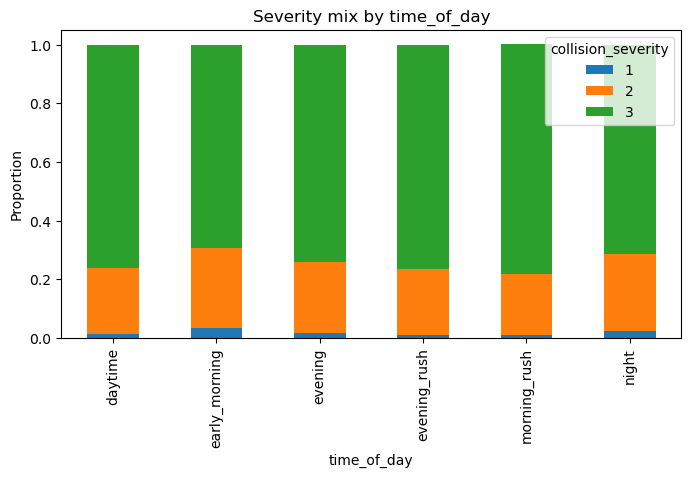

In [31]:
# Example for time_of_day
ct = pd.crosstab(df_feat["time_of_day"], df_feat[TARGET], normalize="index").round(4)
print(ct)
ct.plot(kind="bar", stacked=True, figsize=(8,4))
plt.title("Severity mix by time_of_day")
plt.ylabel("Proportion")
plt.show()

In [32]:
df_grid = create_grid_cell(df)

grid = (
    df_grid.groupby("grid_cell")
    .agg(
        total_collisions=("collision_severity", "size"),
        fatal=("collision_severity", lambda x: (x == 1).sum()),
        serious=("collision_severity", lambda x: (x == 2).sum()),
        slight=("collision_severity", lambda x: (x == 3).sum()),
        lat=("latitude", "mean"),
        lon=("longitude", "mean"),
    )
    .reset_index()
)

# Severity index
# Fatal counts more than Serious
grid["severity_index"] = (
    (grid["fatal"] * 5 + grid["serious"] * 2 + grid["slight"] * 1)
    / grid["total_collisions"]
)

grid["severe_rate"] = (grid["fatal"] + grid["serious"]) / grid["total_collisions"]

print(grid.describe())
grid.head()

       total_collisions         fatal       serious        slight  \
count      76014.000000  76014.000000  76014.000000  76014.000000   
mean           6.757939      0.099324      1.536388      5.122227   
std           16.326619      0.326116      3.231651     13.407855   
min            1.000000      0.000000      0.000000      0.000000   
25%            1.000000      0.000000      0.000000      1.000000   
50%            2.000000      0.000000      1.000000      2.000000   
75%            6.000000      0.000000      2.000000      4.000000   
max          574.000000      5.000000    122.000000    450.000000   

                lat           lon  severity_index   severe_rate  
count  76014.000000  76014.000000    76014.000000  76014.000000  
mean      52.744240     -1.710884        1.407819      0.316669  
std        1.624463      1.576624        0.618492      0.354890  
min       49.912590     -7.486852        1.000000      0.000000  
25%       51.500882     -2.809675        1.00000

,grid_cell,total_collisions,fatal,serious,slight,lat,lon,severity_index,severe_rate
0,49.91_-6.3,3,0,1,2,49.912590,-6.300487,1.333333,0.333333
1,49.91_-6.32,2,0,0,2,49.914428,-6.316358,1.000000,0.000000
2,49.92_-6.3,2,0,0,2,49.916459,-6.298911,1.000000,0.000000
3,49.92_-6.31,2,0,2,0,49.924368,-6.307847,2.000000,1.000000
4,49.98_-5.2,1,0,1,0,49.975225,-5.204205,2.000000,1.000000


In [33]:
# Final feature set (drop raw lat/lon and temporary cols)
drop_cols = ["date", "time", "latitude", "longitude", "lat_bin", "lon_bin"]
df_final = df_feat.drop(columns=[c for c in drop_cols if c in df_feat.columns])

df_final.to_parquet(FEATURES_FILE, index=False)
grid.to_parquet(GRID_RISK_FILE, index=False)

print("Saved:", FEATURES_FILE)
print("Saved:", GRID_RISK_FILE)

# Export column lists for Owner 3
cat_cols, num_cols = get_feature_columns()
print("CATEGORICAL:", cat_cols)
print("NUMERIC:", num_cols)

Saved: E:\Intelij IDEA\IdeaProjects\ML Final Project\roadsafe-ai\ml\data\processed\collisions_features.parquet
Saved: E:\Intelij IDEA\IdeaProjects\ML Final Project\roadsafe-ai\ml\data\processed\grid_risk.parquet
CATEGORICAL: ['time_of_day', 'is_weekend', 'road_type', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'urban_or_rural_area', 'junction_detail', 'adverse_conditions', 'speed_x_roadtype', 'first_road_class']
NUMERIC: ['hour', 'month', 'day_of_year', 'speed_limit', 'grid_risk']


## Techniques used 


| # | Technique | What we created | Why it should help |
|---|-----------|-----------------|--------------------|
| 1 | Date/time extraction | `hour`, `month`, `day_of_year` | Raw date/time strings are useless to a model; the components carry the temporal risk pattern |
| 2 | Binning | `time_of_day` (6 behavioural buckets) | 24 separate hour values fragment the data; rush-hour / night buckets keep the real signal |
| 3 | New feature | `is_weekend` | Weekend traffic mix is different (less commuting, more leisure and night driving) |
| 4 | Interaction | `adverse_conditions` | Rain on an already wet surface is worse than either factor alone |
| 5 | Interaction | `speed_x_roadtype` | 60 mph on a single carriageway is a very different risk from 60 mph on a dual carriageway |
| 6 | Geographic aggregation | `grid_cell` → `grid_risk` | Raw lat/lon would teach a meaningless linear trend; cells turn location into historical severity |
| 7 | Grouping rare categories | rare codes → 99 | Tiny categories add noise and encourage overfitting |
| 8 | Encoding | one-hot (via Owner 3 Pipeline) | Category codes are labels, not ordered quantities |
| 9 | Scaling | standardise numeric columns | Logistic Regression is scale-sensitive; speed_limit would otherwise dominate hour |

### Validation
Every feature was checked with a normalised crosstab against `collision_severity`. We looked for differences in the Fatal / Serious mix across buckets. Features that showed almost no variation were redesigned or dropped. We do **not** keep features just to reach a count of six.

### Critical framing
The model predicts **collision severity given that a collision occurs**.  
It does **not** predict the probability that a collision will happen.  
STATS19 only records collisions that were reported; there is no record of the millions of safe journeys, so a true accident probability cannot be computed. We therefore present a **relative safety score** that compares routes against each other.